In [2]:
# Cell 1 -- Imports and setup
# We need access to the functions we already wrote in src/data_prep.py,
# so we add the src folder to Python's search path before importing from it.
import sys, os
sys.path.append(os.path.abspath("../src"))

import numpy as np
import matplotlib.pyplot as plt

from data_prep import load_and_preprocess_data, CLASS_NAMES

In [3]:
# Cell 2 -- Load the data
# This reuses the exact function from Step 2, so we know the data
# arriving here is already normalized and correctly shaped.
X_train , y_train , X_test , y_test = load_and_preprocess_data()

Raw shapes -- X_train: (60000, 28, 28), X_test: (10000, 28, 28)
Raw dtype: uint8, raw value range: 0-255
After normalization -- dtype: float32, value range: 0.0-1.0
After reshaping -- X_train: (60000, 28, 28, 1), X_test: (10000, 28, 28, 1)


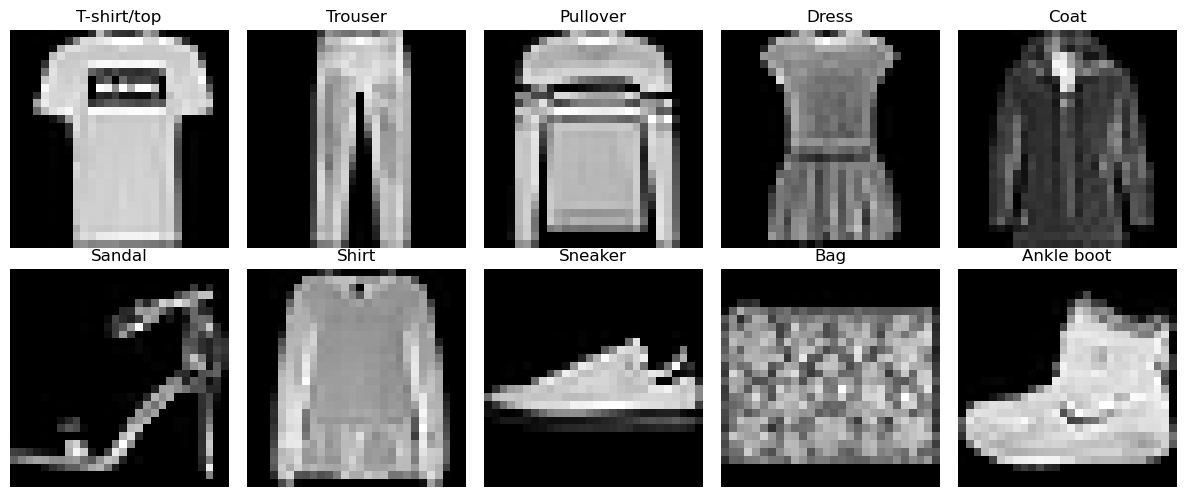

In [4]:
# Cell 3 -- plot_sample_grid(): visually confirm images match their labels
def plot_sample_grid(X , y , class_names):
    """
    Displays one example image from each class, in a 2x5 grid,
    so we can visually confirm the data and labels look correct.
    """
    plt.figure(figsize=(12,5))
    
    for class_index in range(10):
        # np.where(y == class_index) returns a tuple of arrays; [0] gets
        # the array of matching row indices, and the second [0] takes
        # just the FIRST matching index -- i.e. the first image of this class.
        first_match_index = np.where(y == class_index )[0][0]
        
        # X has shape (num_images, 28, 28, 1) -- matplotlib's imshow()
        # expects a 2D array for grayscale, so we drop the channel
        # dimension with [:, :, 0] before plotting.
        image=X[first_match_index][:,:,0]
        
        # subplot(2, 5, position) arranges plots in a 2-row, 5-column grid.
        # position is 1-indexed, so we add 1 to our 0-indexed class_index.
        plt.subplot(2, 5, class_index + 1)
        plt.imshow(image, cmap="gray")
        plt.title(class_names[class_index])
        plt.axis("off")  # pixel coordinates aren't meaningful to show here
        
    plt.tight_layout()
    plt.show()
plot_sample_grid(X_train, y_train, CLASS_NAMES)

Class distribution:
  T-shirt/top    : 6000
  Trouser        : 6000
  Pullover       : 6000
  Dress          : 6000
  Coat           : 6000
  Sandal         : 6000
  Shirt          : 6000
  Sneaker        : 6000
  Bag            : 6000
  Ankle boot     : 6000


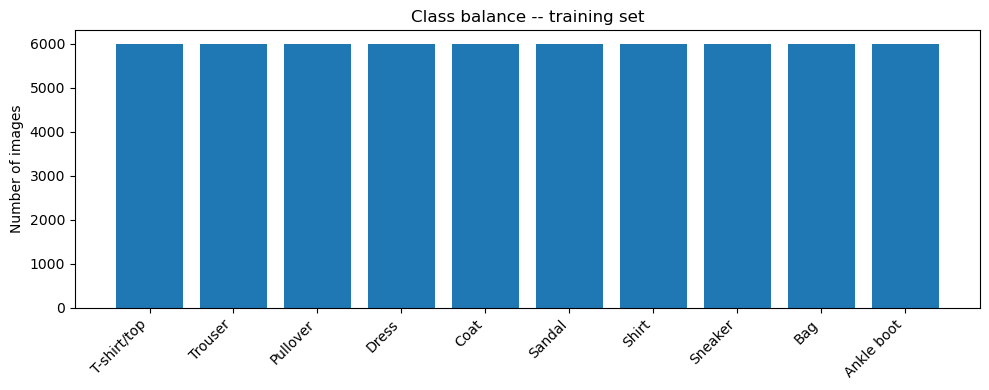

In [5]:
# Cell 4 -- check_class_balance(): confirm the dataset is evenly balanced

def check_class_balance(y, class_names):
    """
    Prints and plots how many examples exist per class, so we verify
    balance rather than assume it.
    """
    # np.unique with return_counts=True gives us two arrays:
    # - unique_classes: the distinct class values found (0-9)
    # - counts: how many times each one appears
    unique_classes, counts = np.unique(y, return_counts=True)

    print("Class distribution:")
    for class_index, count in zip(unique_classes, counts):
        print(f"  {class_names[class_index]:15}: {count}")

    plt.figure(figsize=(10, 4))
    plt.bar([class_names[i] for i in unique_classes], counts)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Number of images")
    plt.title("Class balance -- training set")
    plt.tight_layout()
    plt.show()


# Run it on the training labels
check_class_balance(y_train, CLASS_NAMES)

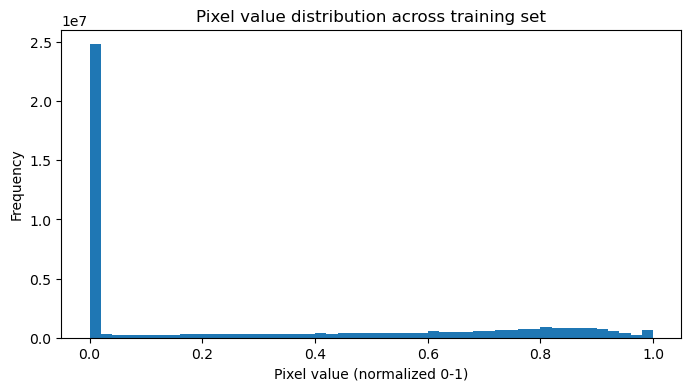

In [6]:
# Cell 5 -- pixel value distribution (optional but useful intuition-builder)

def plot_pixel_distribution(X):
    """
    Plots a histogram of all pixel values across the dataset.
    Helps build intuition about what 'normal' pixel intensity looks like
    before we start inspecting feature maps later in the project.
    """
    # X has shape (num_images, 28, 28, 1) -- flatten() collapses this
    # into one long 1D array of every single pixel value across every image,
    # so we can look at the overall distribution regardless of position.
    all_pixels = X.flatten()

    plt.figure(figsize=(8, 4))
    plt.hist(all_pixels, bins=50)
    plt.xlabel("Pixel value (normalized 0-1)")
    plt.ylabel("Frequency")
    plt.title("Pixel value distribution across training set")
    plt.show()


plot_pixel_distribution(X_train)